# Rows in, rows out

**Week 2, Tuesday. Round 2 of 3, notebook 2 of 4.** By the end of this notebook you can write the
row-count reconciliation above a joined number before you run it, show how an INNER join at the
right grain quietly removes the unpaid orders, and build the bridge from booked to what the
payments feed posted.

> **The client asks.** "Show me, order by order, what we actually collected against what we booked
> in Q2. If there is a gap, I want to know which orders and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

> **Kavya's review.** "Rows in, rows out, and the difference explained, written above the number.
> If the count does not close, the number does not leave the team."

Round 1 found the fan-out and fixed it at order grain: 462 Q2 orders went in, 462 rows came out,
booked came back to Rs 9,84,00,000, and payments as the feed posted them came to Rs 9,66,65,820.
That report is honest about its grain and still silent about two things Anand needs: which orders
make up the difference, and whether any payment was counted twice.

**Setup.** The next cell finds the helper by walking up from this folder, connects to the Kalpa
warehouse and recreates the invented tiny tables as TEMP tables on this notebook's one connection.
The queries follow `sql/C2_W02_D02_03_reconcile_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

TINY = """
DROP TABLE IF EXISTS tiny_orders, tiny_payments;
CREATE TEMP TABLE tiny_orders (order_id text PRIMARY KEY, channel text, amount numeric(12, 2), status text);
CREATE TEMP TABLE tiny_payments (payment_id text PRIMARY KEY, order_id text, paid_date date,
                                 amount numeric(12, 2), instalment_no integer);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app', 1000, 'delivered'), ('T-2', 'web', 2000, 'delivered'),
    ('T-3', 'store', 1500, 'delivered'), ('T-4', 'app', 800, 'delivered'),
    ('T-5', 'store', 500, 'delivered');
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1), ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05', 800, 2), ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1), ('P-6', 'T-5', '2026-07-12', 500, 1),
    ('P-7', 'T-9', '2026-07-14', 600, 1);
"""

from decimal import Decimal

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)          # invented tables, TEMP, so they vanish with this session


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def show(rows, caption="", money=()):
    """Set the rows as the kit's table, with the named columns in Rs and NULL written out."""
    headers = list(rows[0]) if rows else ["result"]
    body = []
    for r in rows:
        line = []
        for h in headers:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(int(v) if v == v.to_integral_value() else float(v))
            else:
                line.append(v)
        body.append(line)
    kit.table(headers, body or [["no rows"]], caption)


def crore(v):
    """A chart label in crore, since eight-digit rupee labels do not fit under a column."""
    return f"{float(v) / 1e7:.2f}"

BRIDGE_SQL = """
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount, count(*) AS times_posted
    FROM payments GROUP BY order_id, instalment_no
),
per_order AS (
    SELECT order_id, sum(amount) AS collected, sum(amount * (times_posted - 1)) AS posted_twice
    FROM per_instalment GROUP BY order_id
)
SELECT sum(o.amount) AS booked,
       coalesce(-sum(o.amount) FILTER (WHERE po.order_id IS NULL), 0) AS less_never_paid,
       sum(coalesce(po.collected, 0)) AS collected,
       sum(coalesce(po.posted_twice, 0)) AS plus_posted_twice,
       sum(coalesce(po.collected, 0) + coalesce(po.posted_twice, 0)) AS posted_in_feed
FROM orders o LEFT JOIN per_order po ON po.order_id = o.order_id
WHERE o.quarter = 'Q2'
"""
KALPA_PER_ORDER_SQL = """
WITH paid_per_order AS (SELECT order_id, sum(amount) AS paid FROM payments GROUP BY order_id)
"""

print("warehouse connected; invented tiny tables ready:", run("SELECT count(*) AS n FROM tiny_orders")[0]["n"],
      "orders and", run("SELECT count(*) AS n FROM tiny_payments")[0]["n"], "payments")

warehouse connected; invented tiny tables ready: 5 orders and 7 payments


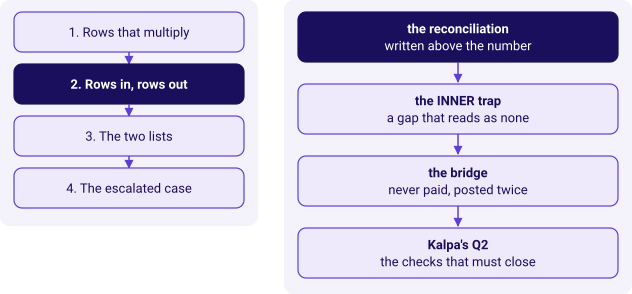

In [2]:
kit.side_by_side(
    kit.ladder(["Rows that multiply", "Rows in, rows out", "The two lists", "The escalated case"],
               lit=1, show=False),
    kit.vflow(["the reconciliation\nwritten above the number",
               "the INNER trap\na gap that reads as none",
               "the bridge\nnever paid, posted twice",
               "Kalpa's Q2\nthe checks that must close"], lit=0, show=False),
)

## 1. A join is done when its row count is explained

The habit is three lines written before the query runs: rows in, rows out, and the difference with
its reason. On the invented tables, rows in is five orders. A plain LEFT JOIN of orders to payments
returns seven rows.

**Predict before you run.** What explains the two extra rows? a) two unpaid orders; b) one second
instalment and one gateway retry; c) the orphan payment and the unpaid order; d) two orphan
payments.

order_id,payment_rows,rows_in_left_join,payments
T-1,1,1,P-1 instalment 1
T-2,2,2,"P-2 instalment 1, P-3 instalment 2"
T-3,2,2,"P-4 instalment 1, P-5 instalment 1"
T-4,0,1,NULL
T-5,1,1,P-6 instalment 1


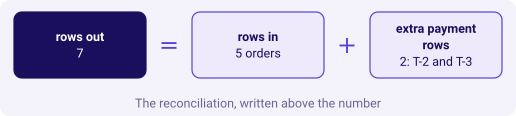

In [3]:
per_order = run("""
SELECT o.order_id,
       count(p.payment_id) AS payment_rows,
       greatest(count(p.payment_id), 1) AS rows_in_left_join,
       string_agg(p.payment_id || ' instalment ' || p.instalment_no, ', ' ORDER BY p.payment_id) AS payments
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id
GROUP BY o.order_id
ORDER BY o.order_id
""")
show(per_order, "Invented: each order's payment rows and the rows it contributes to the LEFT JOIN")
rows_in = len(per_order)
rows_out = sum(r["rows_in_left_join"] for r in per_order)
kit.equation([f"rows out\n{rows_out}", "=", f"rows in\n{rows_in} orders", "+",
              f"extra payment rows\n{rows_out - rows_in}: T-2 and T-3"],
             title="The reconciliation, written above the number")

**What happened.** The answer is b. T-2's second instalment adds one row and T-3's retry adds one
row; T-4 still contributes one row, full of NULLs on the payment side, and P-7 contributes none
because a LEFT JOIN from orders never reaches a payment whose order is missing. The equation is what
Kavya means by written above the number: the difference has a name before anybody sums a column.

In [4]:
kit.check("rows out equal rows in plus the extra payment rows",
          rows_out == rows_in + sum(max(r["payment_rows"] - 1, 0) for r in per_order), f"{rows_out} = {rows_in} + 2")
kit.check("the unpaid order still contributes one row to a LEFT JOIN",
          [r["rows_in_left_join"] for r in per_order if r["payment_rows"] == 0] == [1], "T-4")
kit.check("exactly two orders repeat", sum(1 for r in per_order if r["payment_rows"] > 1) == 2, "T-2 and T-3")

## 2. An INNER join at the right grain hides the unpaid order

**The plausible wrong answer.** Round 1's lesson was learnt: payments are brought to one row per
order first. The analyst then joins with a plain `JOIN`, because "we only care about orders that
have payments", and reports booked, collected and the gap.

**Predict before you run.** On the invented tables, where T-4 (800) was never paid, what gap does
this report print? a) 800, the unpaid order; b) 0; c) minus 1,500; d) minus 700.

In [5]:
inner_report = run("""
WITH paid_per_order AS (
    SELECT order_id, sum(amount) AS paid FROM tiny_payments GROUP BY order_id
)
SELECT count(*) AS orders_in_report,
       sum(o.amount) AS booked,
       sum(pp.paid) AS collected,
       sum(o.amount) - sum(pp.paid) AS gap
FROM tiny_orders o
JOIN paid_per_order pp ON pp.order_id = o.order_id
""")[0]
show([inner_report], "Invented: the INNER report at order grain", money=["booked", "collected", "gap"])

orders_in_report,booked,collected,gap
4,"Rs 5,000","Rs 6,500","-Rs 1,500"


**Why it is wrong.** The answer is c. The report says the quarter is fully collected with a surplus
of 1,500, and the decision it invites is to tell Anand there is no gap, so nobody chases T-4. Two
errors cancel into a comfortable number: the INNER join removed T-4 from booked, and T-3's retry
still sits inside collected. The check that exposes it is the count in the first column: the report
holds four orders and the table holds five.

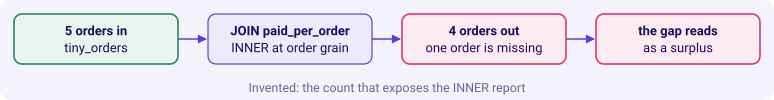

In [6]:
orders_in_table = run("SELECT count(*) AS n FROM tiny_orders")[0]["n"]
kit.flow([f"{orders_in_table} orders in\ntiny_orders", "JOIN paid_per_order\nINNER at order grain",
          f"{inner_report['orders_in_report']} orders out\none order is missing", "the gap reads\nas a surplus"],
         kinds=["good", "plain", "bad", "bad"], title="Invented: the count that exposes the INNER report")
kit.check("the check catches it: the INNER report holds fewer orders than the table",
          inner_report["orders_in_report"] < orders_in_table,
          f'{inner_report["orders_in_report"]} against {orders_in_table}')
kit.check("the INNER report's booked is short by exactly the unpaid order",
          run("SELECT sum(amount) AS s FROM tiny_orders")[0]["s"] - inner_report["booked"] == 800, "T-4, 800")

**The fix.** LEFT JOIN keeps every order, and `COALESCE(pp.paid, 0)` turns the unpaid order's
missing payment into a zero, so it counts in booked and adds nothing to collected. Rows in and rows
out now match, five and five.

orders_in_report,booked,collected_as_posted,gap
5,"Rs 5,800","Rs 6,500",-Rs 700


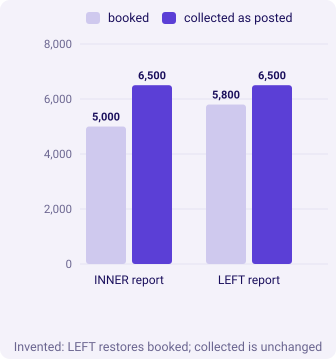

In [7]:
left_report = run("""
WITH paid_per_order AS (
    SELECT order_id, sum(amount) AS paid FROM tiny_payments GROUP BY order_id
)
SELECT count(*) AS orders_in_report,
       sum(o.amount) AS booked,
       sum(coalesce(pp.paid, 0)) AS collected_as_posted,
       sum(o.amount) - sum(coalesce(pp.paid, 0)) AS gap
FROM tiny_orders o
LEFT JOIN paid_per_order pp ON pp.order_id = o.order_id
""")[0]
show([left_report], "Invented: the LEFT report at order grain", money=["booked", "collected_as_posted", "gap"])
kit.columns(["INNER report", "LEFT report"],
            [("booked", [float(inner_report["booked"]), float(left_report["booked"])]),
             ("collected as posted", [float(inner_report["collected"]), float(left_report["collected_as_posted"])])],
            title="Invented: LEFT restores booked; collected is unchanged")

In [8]:
kit.check("the LEFT report holds every order", left_report["orders_in_report"] == orders_in_table,
          f'{left_report["orders_in_report"]} orders')
kit.check("booked in the LEFT report equals booked in the table", left_report["booked"] == 5800, "5,800")
kit.check("the gap is still negative, because the retry sits inside collected", left_report["gap"] == -700,
          "minus 700 = 800 unpaid less 1,500 posted twice")

**Your turn on Kalpa.** Run the same two reports on Q2 and write the three reconciliation lines
above them before you read the totals. Type these lines into the empty cell below:

```python
inner_q2 = run("""
WITH paid_per_order AS (SELECT order_id, sum(amount) AS paid FROM payments GROUP BY order_id)
SELECT count(*) AS orders_in_report, sum(o.amount) AS booked, sum(pp.paid) AS collected,
       sum(o.amount) - sum(pp.paid) AS gap
FROM orders o JOIN paid_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2'
""")
show(inner_q2, "Q2, INNER at order grain", money=["booked", "collected", "gap"])
```

Then say in one sentence what the INNER report would have told Anand, and how many Q2 orders it
left out.

In [9]:
_inner = run(KALPA_PER_ORDER_SQL + """
SELECT count(*) AS n, sum(o.amount) AS booked, sum(pp.paid) AS paid
FROM orders o JOIN paid_per_order pp ON pp.order_id = o.order_id WHERE o.quarter = 'Q2'""")[0]
_left = run(KALPA_PER_ORDER_SQL + """
SELECT count(*) AS n, sum(o.amount) AS booked, sum(coalesce(pp.paid, 0)) AS paid
FROM orders o LEFT JOIN paid_per_order pp ON pp.order_id = o.order_id WHERE o.quarter = 'Q2'""")[0]
kit.check("on Kalpa, the INNER report holds fewer orders than the quarter", _inner["n"] < _left["n"] == 462)
kit.check("on Kalpa, the INNER report's gap reads as a surplus, the same shape as the invented one",
          _inner["booked"] - _inner["paid"] < 0)
kit.check("on Kalpa, the LEFT report's booked equals booked from orders alone", _left["booked"] == 98400000)

## 3. The bridge splits the gap into what was never paid and what was posted twice

A negative gap in a business that is owed money means some payments are counted more than once.
The bridge walks from booked to what the feed posted in named moves, so every rupee of difference
has a reason: take away the orders never paid, which lands on what was truly collected, then add
back the instalments the gateway posted twice, which lands on what the feed shows.

**Predict before you run.** The LEFT report's gap on the invented tables is minus 700. What is it
made of? a) T-4's 800 never paid, less T-3's 1,500 posted twice; b) the orphan payment P-7 of 600
and 100 of rounding; c) T-2's second instalment of 800, less 1,500; d) an error introduced by
COALESCE.

booked,less_never_paid,collected,plus_posted_twice,posted_in_feed
"Rs 5,800",-Rs 800,"Rs 5,000","Rs 1,500","Rs 6,500"


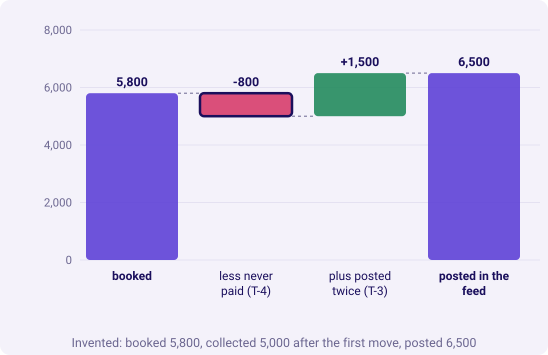

In [10]:
b = run("""
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount, count(*) AS times_posted
    FROM tiny_payments
    GROUP BY order_id, instalment_no
),
per_order AS (
    SELECT order_id, sum(amount) AS collected, sum(amount * (times_posted - 1)) AS posted_twice
    FROM per_instalment
    GROUP BY order_id
)
SELECT sum(o.amount) AS booked,
       -sum(o.amount) FILTER (WHERE po.order_id IS NULL) AS less_never_paid,
       sum(coalesce(po.collected, 0)) AS collected,
       sum(coalesce(po.posted_twice, 0)) AS plus_posted_twice,
       sum(coalesce(po.collected, 0) + coalesce(po.posted_twice, 0)) AS posted_in_feed
FROM tiny_orders o
LEFT JOIN per_order po ON po.order_id = o.order_id
""")[0]
show([b], "Invented: the bridge in one row", money=list(b))
kit.bridge(("booked", float(b["booked"])),
           [("less never paid (T-4)", float(b["less_never_paid"])),
            ("plus posted twice (T-3)", float(b["plus_posted_twice"]))],
           end_label="posted in the feed", lit=[0], fmt=lambda v: f"{v:,.0f}",
           title="Invented: booked 5,800, collected 5,000 after the first move, posted 6,500")

**What happened.** The answer is a. Booked 5,800 less the 800 never paid is 5,000, which is what
the business truly collected; plus the 1,500 the gateway posted a second time is 6,500, which is
what the feed shows. The minus 700 was the two moves netted into one number, and a netted number
hides both of the things Anand asked about. P-7 does not appear, because it belongs to no order in
the quarter; it goes back to the data platform lead as a question of its own.

In [11]:
kit.check("the bridge closes: booked plus both moves equals what the feed posted",
          b["booked"] + b["less_never_paid"] + b["plus_posted_twice"] == b["posted_in_feed"], "5,800 - 800 + 1,500 = 6,500")
kit.check("collected equals booked less never paid", b["collected"] == b["booked"] + b["less_never_paid"], "5,000")
kit.check("posted in the feed equals the payments that belong to an order",
          b["posted_in_feed"] == run("SELECT sum(amount) AS s FROM tiny_payments WHERE order_id IN (SELECT order_id FROM tiny_orders)")[0]["s"],
          "6,500, with P-7 left out")

## 4. On Kalpa, the number leaves the team only when the checks close

Q2 at order grain, from round 1, with the reconciliation lines written first. Rows in: 462 Q2
orders from `orders` alone. Rows out: one row per order after the join. The difference: none,
because payments are aggregated before the join.

**Predict before you run.** Which of these has to hold before the Q2 number goes to Anand?
a) rows out equal rows in; b) rows out equal rows in, and booked matches the orders table;
c) everything in b, and booked less never paid plus posted twice lands on what the feed posted
against Q2 orders; d) collected equals booked.

rows_in,rows_out,booked,paid_as_posted
462,462,"Rs 9,84,00,000","Rs 9,66,65,820"


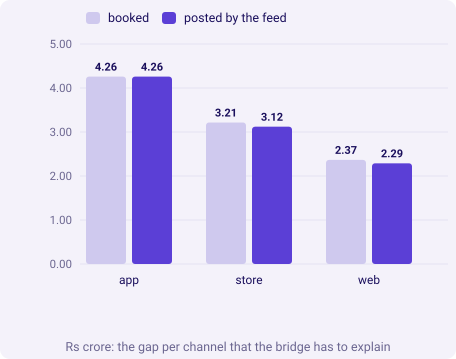

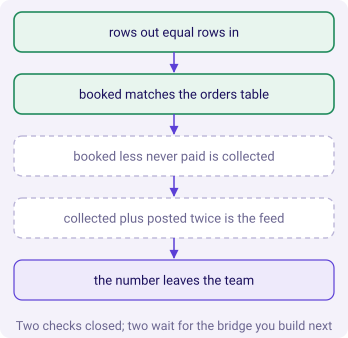

In [12]:
stamp = run(KALPA_PER_ORDER_SQL + """
SELECT (SELECT count(*) FROM orders WHERE quarter = 'Q2') AS rows_in,
       count(*) AS rows_out,
       sum(o.amount) AS booked,
       sum(coalesce(pp.paid, 0)) AS paid_as_posted
FROM orders o
LEFT JOIN paid_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2'
""")
show(stamp, "Q2 at order grain: the lines written above the number", money=["booked", "paid_as_posted"])
by_channel = run(KALPA_PER_ORDER_SQL + """
SELECT o.channel, sum(o.amount) AS booked, sum(coalesce(pp.paid, 0)) AS posted
FROM orders o LEFT JOIN paid_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2' GROUP BY o.channel ORDER BY o.channel""")
kit.columns([r["channel"] for r in by_channel],
            [("booked", [float(r["booked"]) for r in by_channel]),
             ("posted by the feed", [float(r["posted"]) for r in by_channel])],
            fmt=crore, title="Rs crore: the gap per channel that the bridge has to explain")
kit.vflow(["rows out equal rows in", "booked matches the orders table",
           "booked less never paid is collected", "collected plus posted twice is the feed",
           "the number leaves the team"],
          kinds=["good", "good", "unknown", "unknown", "plain"],
          title="Two checks closed; two wait for the bridge you build next")

**What happened.** The answer is c. Rows and booked close, which proves the join did not multiply
or drop anything; they say nothing about whether the payments inside the number are real
collections. Only the bridge proves that, and the two dashed boxes are yours to close.

**Your turn.** Type these lines into the empty cell below and run them. Read the never-paid move and
the posted-twice move as two questions for Anand before you read the totals.

```python
kb = run("""
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount, count(*) AS times_posted
    FROM payments GROUP BY order_id, instalment_no
),
per_order AS (
    SELECT order_id, sum(amount) AS collected, sum(amount * (times_posted - 1)) AS posted_twice
    FROM per_instalment GROUP BY order_id
)
SELECT sum(o.amount) AS booked,
       coalesce(-sum(o.amount) FILTER (WHERE po.order_id IS NULL), 0) AS less_never_paid,
       sum(coalesce(po.collected, 0)) AS collected,
       sum(coalesce(po.posted_twice, 0)) AS plus_posted_twice,
       sum(coalesce(po.collected, 0) + coalesce(po.posted_twice, 0)) AS posted_in_feed
FROM orders o LEFT JOIN per_order po ON po.order_id = o.order_id
WHERE o.quarter = 'Q2'
""")[0]
show([kb], "Q2: the bridge in one row", money=list(kb))
kit.bridge(("booked", float(kb["booked"])),
           [("less never paid", float(kb["less_never_paid"])),
            ("plus posted twice", float(kb["plus_posted_twice"]))],
           end_label="posted in the feed", lo=9.6e7, fmt=lambda v: f"{v / 1e5:,.2f}",
           title="Q2 in Rs lakh, axis from 960 lakh so the moves show")
```

In [13]:
_b = run(BRIDGE_SQL)[0]
_feed = run("""SELECT sum(p.amount) AS s FROM payments p JOIN orders o ON o.order_id = p.order_id
               WHERE o.quarter = 'Q2'""")[0]["s"]
kit.check("the Kalpa bridge closes: booked plus both moves equals what the feed posted",
          _b["booked"] + _b["less_never_paid"] + _b["plus_posted_twice"] == _b["posted_in_feed"])
kit.check("posted in the bridge equals the feed's own total against Q2 orders", _b["posted_in_feed"] == _feed)
kit.check("collected sits below booked once the retries are taken out", _b["collected"] < _b["booked"])
kit.check("both moves are non-zero, so both of Anand's questions have an answer",
          _b["less_never_paid"] < 0 and _b["plus_posted_twice"] > 0)

> **Kavya's review.** "Rows in, rows out, and the difference explained, written above the number.
> If the count does not close, the number does not leave the team."

The four checks above passed without printing a rupee, which is the point: the reconciliation is a
property of the query, and it holds whatever the totals turn out to be. Round 3 turns the two moves
into two lists, the orders never paid and the payments posted twice, because Anand asked which
orders and which channel.

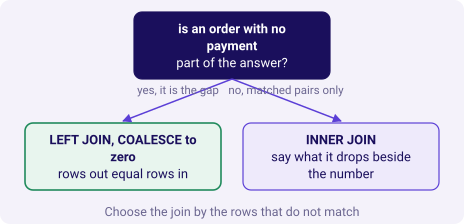

What you can now say,The evidence
A joined number carries its row count above it,rows out 7 = rows in 5 + 2 extra payment rows
INNER at the right grain can still hide the gap,"invented: 4 orders of 5, gap minus 1,500"
LEFT restores booked and leaves the retry inside collected,invented: gap minus 700
The bridge names both moves,"invented: 5,800 less 800 is 5,000; plus 1,500 is 6,500"
On Kalpa the four checks close,"rows, booked, bridge and feed all reconcile"


In [14]:
kit.tree({"label": "is an order with no payment\npart of the answer?", "kind": "lit", "branches": [
    ("yes, it is the gap", {"label": "LEFT JOIN, COALESCE to zero\nrows out equal rows in", "kind": "good"}),
    ("no, matched pairs only", {"label": "INNER JOIN\nsay what it drops beside the number"})]},
    taken=["yes, it is the gap"], title="Choose the join by the rows that do not match")
kit.table(["What you can now say", "The evidence"],
          [["A joined number carries its row count above it", "rows out 7 = rows in 5 + 2 extra payment rows"],
           ["INNER at the right grain can still hide the gap", "invented: 4 orders of 5, gap minus 1,500"],
           ["LEFT restores booked and leaves the retry inside collected", "invented: gap minus 700"],
           ["The bridge names both moves", "invented: 5,800 less 800 is 5,000; plus 1,500 is 6,500"],
           ["On Kalpa the four checks close", "rows, booked, bridge and feed all reconcile"]],
          caption="What round 2 established")

### In the interview

**[F] How do you reconcile a total after a join back to its source table?** "I compute the total
twice: once from the source table alone, before any join, and once from the joined result, and the
two must be equal to the rupee. For Kalpa's Q2, booked from orders alone is Rs 9,84,00,000, and the
joined report must print the same. Then I do the same for the other table: the payments total in
the report must equal the feed's own total against those orders. If either differs, the join has
multiplied or dropped rows, and the row count tells me which."

**[D] Design the validation you run before a joined number reaches Finance, and say what you do
when it fails at 5 pm on reporting day.** "Four checks, written as queries that return true or
false and run on every refresh: rows out equal rows in at the report's grain; the summed measure
from each side equals its source total; the gap is explained by named moves, here never paid and
posted twice, and the moves close exactly; and every row of the child table is accounted for as
matched or orphaned. If one fails late on reporting day, the number does not go out as final. I
send the last reconciled number with its date, say in one line which check failed and by how much,
and give a time by which the corrected number will follow. A late number with a stated reason is
recoverable; a wrong number Finance has already booked is not."

**[D] Anand says the gap is too small to matter; how do you decide whether to chase it?** "I size
it three ways before agreeing. In rupees against what one follow-up costs; in orders, because a few
large unpaid invoices are a different problem from many small ones; and in age, because an unpaid
order from early in the quarter is overdue while one from last week may simply be in transit. I
also check whether the net gap hides two larger moves that cancel, since a small net number can
sit on top of real unpaid orders and real double postings, and each of those has an owner."

### Depth: three SQL details the reconciliation leans on

`count(*)` counts rows and `count(pp.order_id)` counts rows where the payment side matched, so in a
LEFT JOIN at order grain the pair gives orders in and orders paid in one line, and their difference
is the unpaid count. `sum()` skips NULLs, while `booked - NULL` is NULL, which is why the gap is
computed from `coalesce(pp.paid, 0)` and never from the raw column. `FILTER (WHERE ...)` restricts
one aggregate without restricting the rows, which is how the bridge sums the booked value of the
never-paid orders beside the totals over every order.

A second way to prove two results agree is set difference: `SELECT order_id FROM orders WHERE
quarter = 'Q2' EXCEPT SELECT order_id FROM report` returns exactly the orders a report lost, and
it should return no rows.

Written reference: PostgreSQL 16 documentation, 7.2 Table Expressions,
https://www.postgresql.org/docs/16/queries-table-expressions.html (verified 29 Sep 2026).

In [15]:
kit.check_summary()
print("Next: round 3 lists the orders never paid and the payments posted twice, with the grain that separates a retry from an instalment.")

Next: round 3 lists the orders never paid and the payments posted twice, with the grain that separates a retry from an instalment.
